## The Self-Pruning Neural Network

Install & Imports Libraries

In [1]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Prunable Linear Layer

In [11]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, temperature=1.0):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

        self.temperature = temperature

    def forward(self, x):

        gates = torch.sigmoid(self.gate_scores / self.temperature)

        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gate_values(self):
        return torch.sigmoid(self.gate_scores / self.temperature)

Network Architecture

In [3]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return [
            self.fc1.get_gate_values(),
            self.fc2.get_gate_values(),
            self.fc3.get_gate_values()
        ]

Load CIFAR-10

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128)

print("Data Loaded")

Data Loaded


In [9]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2470,0.2435,0.2616))
])

Loss Functions

In [5]:
def compute_sparsity_loss(model):
    loss = 0.0
    for gates in model.get_all_gates():
        loss += gates.sum()
    return loss

Evaluation + Sparsity

In [6]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


def calculate_sparsity(model, threshold=0.1):
    total, zero = 0, 0

    for gates in model.get_all_gates():
        total += gates.numel()
        zero += (gates < threshold).sum().item()

    return 100 * zero / total

Training Function

In [7]:
def train_model(lambda_val, epochs=10):
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    epoch_accs = []
    epoch_sparsities = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)

            cls_loss = criterion(out, y)
            sparsity_loss = compute_sparsity_loss(model)

            loss = cls_loss + lambda_val * sparsity_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()


        acc = evaluate(model)
        sparsity = calculate_sparsity(model)

        epoch_accs.append(acc)
        epoch_sparsities.append(sparsity)

        print(f"Epoch {epoch+1}: Loss={total_loss:.2f}, Accuracy={acc:.2f}%, Sparsity={sparsity:.2f}%")

    return model, acc, sparsity, epoch_accs, epoch_sparsities

Run Experiments

In [12]:
lambdas = [0.005, 0.01, 0.02]
results = []

for lam in lambdas:
    print(f"\nTraining with λ = {lam}")
    model, acc, sparsity, _, _ = train_model(lam)
    results.append((lam, acc, sparsity))


Training with λ = 0.005
Epoch 1: Loss=1535632.28, Accuracy=46.35%, Sparsity=0.00%
Epoch 2: Loss=1274247.62, Accuracy=50.07%, Sparsity=0.00%
Epoch 3: Loss=1033127.25, Accuracy=51.38%, Sparsity=0.01%
Epoch 4: Loss=822761.55, Accuracy=52.85%, Sparsity=0.03%
Epoch 5: Loss=648581.89, Accuracy=53.36%, Sparsity=0.08%
Epoch 6: Loss=510226.31, Accuracy=53.94%, Sparsity=0.16%
Epoch 7: Loss=403088.14, Accuracy=53.94%, Sparsity=0.32%
Epoch 8: Loss=320915.77, Accuracy=53.71%, Sparsity=0.58%
Epoch 9: Loss=257766.74, Accuracy=53.25%, Sparsity=1.02%
Epoch 10: Loss=208833.58, Accuracy=53.09%, Sparsity=1.71%

Training with λ = 0.01
Epoch 1: Loss=3067690.12, Accuracy=46.87%, Sparsity=0.00%
Epoch 2: Loss=2544878.79, Accuracy=50.87%, Sparsity=0.00%
Epoch 3: Loss=2062759.63, Accuracy=51.93%, Sparsity=0.01%
Epoch 4: Loss=1642343.34, Accuracy=52.85%, Sparsity=0.04%
Epoch 5: Loss=1294413.09, Accuracy=53.45%, Sparsity=0.08%
Epoch 6: Loss=1018134.00, Accuracy=53.41%, Sparsity=0.16%
Epoch 7: Loss=804232.62, Accu

Show Results Table

In [13]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity")

for lam, acc, sparsity in results:
    print(f"{lam} | {acc:.2f}% | {sparsity:.2f}%")


Final Results:
Lambda | Accuracy | Sparsity
0.005 | 53.09% | 1.71%
0.01 | 51.95% | 1.72%
0.02 | 50.94% | 1.71%


GATE DISTRIBUTION PLOT

In [20]:
def plot_gate_distribution(model):
    """
    Plots histogram of all gate values across the network.
    """

    all_gates = []

    # Collect all gate values
    for gates in model.get_all_gates():
        all_gates.append(gates.detach().cpu().numpy().flatten())

    # Combine into single array
    all_gates = np.concatenate(all_gates)

    # Plot histogram
    plt.figure()
    plt.hist(all_gates, bins=50)

    plt.xlabel("Gate Value (0 to 1)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Gate Values")

    plt.grid()
    plt.show()

    # Optional: Print stats (helps explanation)
    print("Min Gate:", all_gates.min())
    print("Max Gate:", all_gates.max())
    print("Mean Gate:", all_gates.mean())

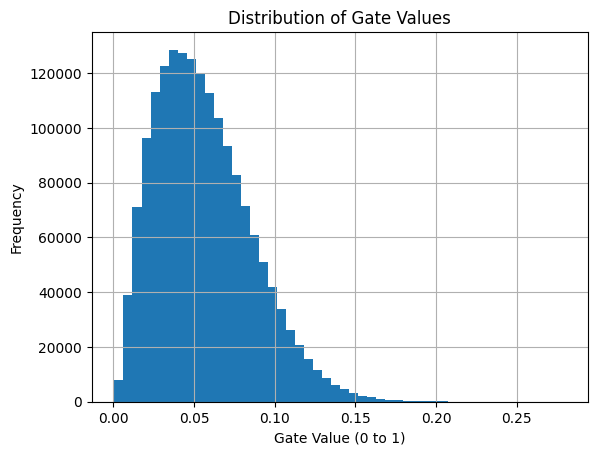

Min Gate: 0.0007719848
Max Gate: 0.2799921
Mean Gate: 0.05610583


In [21]:
plot_gate_distribution(model)

## Gate Distribution Analysis

Most gate values are small (around 0 to 0.1) with an average of about 0.056.This shows the model is reducing the importance of many weights. Some gates are close to zero, but there is no strong spike at zero, so very few weights are fully pruned.
Overall, sparsity is low (~1.7%), which means the pruning effect is weak. A higher λ or stronger regularization could improve pruning.

## Conclusion

The self-pruning network successfully learned the classification task while demonstrating the effect of sparsity regularization. Although the achieved sparsity is relatively low (~1.7%), the results clearly show the trade-off between accuracy and pruning strength. This indicates that the model is learning to reduce weight importance, but stronger regularization or improved gating strategies would be needed for more effective pruning. Overall, the approach validates the concept of self-pruning during training.